# Chapter 13 - Berquist-Sherman Techniques


In [1]:
import numpy as np
import pandas as pd
import chainladder as cl
import matplotlib.pyplot as plt
from IPython.display import display


## P294 (Exhibit I Sheet 1)


In [2]:
mm = cl.load_sample("friedland_med_mal")
reported = mm["Reported Claims"]

# Part 1
exhibit_i_s1_tri = reported.to_frame(origin_as_datetime=False)
display(exhibit_i_s1_tri)

# Part 2 
display(np.round(reported.link_ratio.to_frame(origin_as_datetime=False), 3))

# Part 3
dev_reported = cl.Development(average="simple").fit(reported)
display(np.round(dev_reported.ldf_.to_frame(), 3))

# Part 4
selected_ldf = {
    12: 2.532,
    24: 1.921,
    36: 1.503,
    48: 1.170,
    60: 1.206,
    72: 1.052,
    84: 1.027,
    96: 1.000,
}
# or this
avg_ldf = np.round(dev_reported.ldf_.to_frame().values.flatten(), 3)
selected_ldf = dict(zip([12, 24, 36, 48, 60, 72, 84, 96], [*avg_ldf, 1.000]))

reported_dev = cl.DevelopmentConstant(patterns=selected_ldf, style="ldf").fit(reported)
cdf = np.round(reported_dev.cdf_.to_frame().values.flatten(), 3) # it's unclear why the text shows different CDFs here, not reconciling using rounded nor unroudned values
pct_reported = np.round(1.0 / cdf, 3)

exhibit_i_s1_sel = pd.DataFrame(
    {
        "Selected": list(selected_ldf.values()),
        "CDF to Ultimate": cdf,
        "Percent Reported": pct_reported,
    },
    index=["12-24", "24-36", "36-48", "48-60", "60-72", "72-84", "84-96", "96-108"],
)
display(exhibit_i_s1_sel.T)


,12,24,36,48,60,72,84,96
1969,2897000.0,5160000.0,10714000.0,15228000.0,16611000.0,20899000.0,22892000.0,23506000.0
1970,4828000.0,10707000.0,16907000.0,22840000.0,26211000.0,31970000.0,32216000.0,NaN
1971,5455000.0,11941000.0,20733000.0,30928000.0,42395000.0,48377000.0,NaN,NaN
1972,8732000.0,18633000.0,32143000.0,57196000.0,61163000.0,NaN,NaN,NaN
1973,11228000.0,19967000.0,50143000.0,73733000.0,NaN,NaN,NaN,NaN
1974,8706000.0,33459000.0,63477000.0,NaN,NaN,NaN,NaN,NaN
1975,12928000.0,48904000.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,15791000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
1969,1.781,2.076,1.421,1.091,1.258,1.095,1.027
1970,2.218,1.579,1.351,1.148,1.220,1.008,NaN
1971,2.189,1.736,1.492,1.371,1.141,NaN,NaN
1972,2.134,1.725,1.779,1.069,NaN,NaN,NaN
1973,1.778,2.511,1.470,NaN,NaN,NaN,NaN
1974,3.843,1.897,NaN,NaN,NaN,NaN,NaN
1975,3.783,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
(All),2.532,1.921,1.503,1.17,1.206,1.052,1.027


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108
Selected,2.532,1.921,1.503,1.170,1.206,1.052,1.027,1.0
CDF to Ultimate,11.145,4.402,2.291,1.524,1.303,1.080,1.027,1.0
Percent Reported,0.090,0.227,0.436,0.656,0.767,0.926,0.974,1.0


In [3]:
# Exhibit I Sheet 1 — reconcile to Friedland PDF p294
exhibit_i_s1_ata = np.round(reported.link_ratio.to_frame(origin_as_datetime=False), 3)
assert np.allclose(
    exhibit_i_s1_ata,
    [
        [1.781, 2.076, 1.421, 1.091, 1.258, 1.095, 1.027],
        [2.218, 1.579, 1.351, 1.148, 1.220, 1.008, np.nan],
        [2.189, 1.736, 1.492, 1.371, 1.141, np.nan, np.nan],
        [2.134, 1.725, 1.779, 1.069, np.nan, np.nan, np.nan],
        [1.778, 2.511, 1.470, np.nan, np.nan, np.nan, np.nan],
        [3.843, 1.897, np.nan, np.nan, np.nan, np.nan, np.nan],
        [3.783, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ],
    equal_nan=True,
)
assert np.allclose(
    np.round(dev_reported.ldf_.to_frame().values.flatten(), 3),
    [2.532, 1.921, 1.503, 1.170, 1.206, 1.052, 1.027],
)
assert np.allclose(
    exhibit_i_s1_sel["CDF to Ultimate"],
    [11.145, 4.402, 2.291, 1.524, 1.303, 1.080, 1.027, 1.000],
    atol=0.01,
)



## P295 (Exhibit I Sheet 2)


In [4]:
paid = mm["Paid Claims"]

# Part 1
exhibit_i_s2_tri = paid.to_frame(origin_as_datetime=False)
display(exhibit_i_s2_tri)

# Part 2
display(np.round(paid.link_ratio.to_frame(origin_as_datetime=False), decimals=3))

# Part 3
dev_paid = cl.Development(average="volume").fit(paid)
avg_ldf = np.round(dev_paid.ldf_.to_frame(origin_as_datetime=False).values.flatten(), 3)
display(np.round(dev_paid.ldf_.to_frame(), 3))

# Part 4
selected_ldf = {
    12: 6.185,
    24: 3.709,
    36: 2.455,
    48: 1.952,
    60: 1.718,
    72: 1.407,
    84: 1.251,
    96: 1.486,
}
# or this
selected_ldf = dict(zip([12, 24, 36, 48, 60, 72, 84, 96], [*avg_ldf, 1.486]))

paid_dev = cl.DevelopmentConstant(patterns=selected_ldf, style="ldf").fit(paid)
cdf = np.round(paid_dev.cdf_.to_frame(origin_as_datetime=False).values.flatten(), 3)
pct_paid = np.round(1.0 / cdf, 3)

exhibit_i_s2_sel = pd.DataFrame(
    {
        "Selected": list(selected_ldf.values()),
        "CDF to Ultimate": cdf,
        "Percent Paid": pct_paid,
    },
    index=["12-24", "24-36", "36-48", "48-60", "60-72", "72-84", "84-96", "96-108"],
)
display(exhibit_i_s2_sel.T)


,12,24,36,48,60,72,84,96
1969,125000.0,406000.0,1443000.0,2986000.0,4467000.0,8179000.0,12638000.0,15815000.0
1970,43000.0,529000.0,2016000.0,3641000.0,7523000.0,14295000.0,18983000.0,NaN
1971,295000.0,1147000.0,2479000.0,5071000.0,11399000.0,17707000.0,NaN,NaN
1972,50000.0,786000.0,3810000.0,9771000.0,18518000.0,NaN,NaN,NaN
1973,213000.0,833000.0,3599000.0,11292000.0,NaN,NaN,NaN,NaN
1974,172000.0,1587000.0,6267000.0,NaN,NaN,NaN,NaN,NaN
1975,210000.0,1565000.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,209000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
1969,3.248,3.554,2.069,1.496,1.831,1.545,1.251
1970,12.302,3.811,1.806,2.066,1.900,1.328,NaN
1971,3.888,2.161,2.046,2.248,1.553,NaN,NaN
1972,15.720,4.847,2.565,1.895,NaN,NaN,NaN
1973,3.911,4.321,3.138,NaN,NaN,NaN,NaN
1974,9.227,3.949,NaN,NaN,NaN,NaN,NaN
1975,7.452,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
(All),6.185,3.709,2.455,1.952,1.718,1.407,1.251


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108
Selected,6.185,3.709,2.455,1.952,1.718,1.407,1.251,1.486
CDF to Ultimate,493.993,79.870,21.534,8.771,4.494,2.616,1.859,1.486
Percent Paid,0.002,0.013,0.046,0.114,0.223,0.382,0.538,0.673


In [5]:
# Exhibit I Sheet 2 — reconcile to Friedland PDF p295
assert np.allclose(
    np.round(dev_paid.ldf_.to_frame().values.flatten(), 3),
    [6.185, 3.709, 2.455, 1.952, 1.718, 1.407, 1.251],
)
assert np.allclose(
    exhibit_i_s2_sel["CDF to Ultimate"],
    [494.097, 79.886, 21.538, 8.773, 4.495, 2.616, 1.859, 1.486],
    atol=0.12,
)
assert np.isclose(exhibit_i_s2_tri.iloc[0, 0], 125000, atol=1)
assert np.isclose(exhibit_i_s2_tri.iloc[-1, 0], 209000, atol=1)


## P296 (Exhibit I Sheet 3)


In [6]:
cl_reported = cl.Chainladder().fit(
    cl.DevelopmentConstant(
        patterns=dict(zip(reported.development, exhibit_i_s1_sel["CDF to Ultimate"])),
        style="cdf",
    ).fit_transform(reported)
)
cl_paid = cl.Chainladder().fit(
    cl.DevelopmentConstant(
        patterns=dict(zip(paid.development, exhibit_i_s2_sel["CDF to Ultimate"])),
        style="cdf",
    ).fit_transform(paid)
)

md_reported = cl.model_diagnostics(cl_reported).to_frame(origin_as_datetime=False).T
md_paid = cl.model_diagnostics(cl_paid).to_frame(origin_as_datetime=False).T

ages = sorted(reported.development, reverse=True)
reported_latest = md_reported["Latest"]
paid_latest = md_paid["Latest"]
ult_reported = md_reported["Ultimate"]
ult_paid = md_paid["Ultimate"]

exhibit_i_s3 = pd.DataFrame(
    {
        "Age (2)": ages,
        "Reported (3)": md_reported["Latest"].values,
        "Paid (4)": md_paid["Latest"].values,
        "CDF Reported (5)": md_reported["CDF"].values,
        "CDF Paid (6)": md_paid["CDF"].values,
        "Ult Reported (7)": md_reported["Ultimate"].values,
        "Ult Paid (8)": md_paid["Ultimate"].values,
    },
    index=md_reported.index,
)
display(exhibit_i_s3)
display(exhibit_i_s3[["Reported (3)", "Paid (4)", "Ult Reported (7)", "Ult Paid (8)"]].sum().to_frame("Total").T)


,Age (2),Reported (3),Paid (4),CDF Reported (5),CDF Paid (6),Ult Reported (7),Ult Paid (8)
origin,,,,,,,
1969,96,23506000.0,15815000.0,1.000,1.486,23506000.0,23501090.0
1970,84,32216000.0,18983000.0,1.027,1.859,33085832.0,35289397.0
1971,72,48377000.0,17707000.0,1.080,2.616,52247160.0,46321512.0
1972,60,61163000.0,18518000.0,1.303,4.494,79695389.0,83219892.0
1973,48,73733000.0,11292000.0,1.524,8.771,112369092.0,99042132.0
1974,36,63477000.0,6267000.0,2.291,21.534,145425807.0,134953578.0
1975,24,48904000.0,1565000.0,4.402,79.870,215275408.0,124996550.0
1976,12,15791000.0,209000.0,11.145,493.993,175990695.0,103244537.0


,Reported (3),Paid (4),Ult Reported (7),Ult Paid (8)
Total,367167000.0,90356000.0,837595383.0,650568688.0


In [7]:
# Exhibit I Sheet 3 — reconcile to Friedland PDF p296
assert np.allclose(
    exhibit_i_s3["Ult Reported (7)"],
    [23506000, 33085832, 52247160, 79695389, 112369092, 145425807, 215275408, 175990695],
    atol=5,
)
assert np.allclose(
    exhibit_i_s3["Ult Paid (8)"],
    [23501090, 35289397, 46321512, 83238410, 99064716, 134978646, 125021590, 103266273],
    rtol=0.0003,
)
assert np.isclose(exhibit_i_s3["Reported (3)"].sum(), 367167000, atol=1)
assert np.isclose(exhibit_i_s3["Paid (4)"].sum(), 90356000, atol=1)
assert np.isclose(exhibit_i_s3["Ult Reported (7)"].sum(), 837595383, atol=50)
assert np.isclose(exhibit_i_s3["Ult Paid (8)"].sum(), 650681634, rtol=0.0003)


## P297 (Exhibit I Sheet 4)


In [8]:
case = mm["Case Outstanding"]
open_counts = mm["Open Claim Counts"]

exhibit_i_s4_case = case.to_frame(origin_as_datetime=False)
display(exhibit_i_s4_case)

exhibit_i_s4_open = open_counts.to_frame(origin_as_datetime=False)
display(exhibit_i_s4_open)

avg_case = case / open_counts
exhibit_i_s4_avg = np.round(avg_case.to_frame(origin_as_datetime=False))
display(exhibit_i_s4_avg)

def exp_trend(tri):
    fit_tri = tri[tri.development < tri.development.max()]
    reg = cl.WeightedRegression(
        axis=2, thru_orig=False, xp=fit_tri.get_array_module()
    ).fit(
        np.ones(fit_tri.shape) * fit_tri.origin.year.values[None, None, :, None],
        np.log(fit_tri.values),
        cl.TriangleWeight().fit(fit_tri).w_.values,
    )
    return np.round(
        pd.DataFrame(
            [np.exp(reg.slope_).flatten() - 1, reg.rsq_.flatten()],
            index=["Annual Change", "R-Squared"],
            columns=fit_tri.development,
        ),
        3,
    )


exhibit_i_s4_trend = exp_trend(avg_case)
display(exhibit_i_s4_trend)


,12,24,36,48,60,72,84,96
1969,2772000.0,4754000.0,9271000.0,12242000.0,12144000.0,12720000.0,10254000.0,7691000.0
1970,4785000.0,10178000.0,14891000.0,19199000.0,18688000.0,17675000.0,13233000.0,NaN
1971,5160000.0,10794000.0,18254000.0,25857000.0,30996000.0,30670000.0,NaN,NaN
1972,8682000.0,17847000.0,28333000.0,47425000.0,42645000.0,NaN,NaN,NaN
1973,11015000.0,19134000.0,46544000.0,62441000.0,NaN,NaN,NaN,NaN
1974,8534000.0,31872000.0,57210000.0,NaN,NaN,NaN,NaN,NaN
1975,12718000.0,47339000.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,15582000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96
1969,749.0,840.0,1001.0,1206.0,1034.0,765.0,533.0,359.0
1970,660.0,957.0,1149.0,1350.0,1095.0,755.0,539.0,NaN
1971,878.0,1329.0,1720.0,1799.0,1428.0,1056.0,NaN,NaN
1972,1043.0,1561.0,1828.0,1894.0,1522.0,NaN,NaN,NaN
1973,1088.0,1388.0,1540.0,1877.0,NaN,NaN,NaN,NaN
1974,1033.0,1418.0,1663.0,NaN,NaN,NaN,NaN,NaN
1975,1138.0,1472.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,1196.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96
1969,3701.0,5660.0,9262.0,10151.0,11745.0,16627.0,19238.0,21423.0
1970,7250.0,10635.0,12960.0,14221.0,17067.0,23411.0,24551.0,NaN
1971,5877.0,8122.0,10613.0,14373.0,21706.0,29044.0,NaN,NaN
1972,8324.0,11433.0,15499.0,25040.0,28019.0,NaN,NaN,NaN
1973,10124.0,13785.0,30223.0,33266.0,NaN,NaN,NaN,NaN
1974,8261.0,22477.0,34402.0,NaN,NaN,NaN,NaN,NaN
1975,11176.0,32160.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,13028.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


development,12,24,36,48,60,72,84
Annual Change,0.156,0.295,0.311,0.342,0.330,0.322,0.276
R-Squared,0.800,0.895,0.858,0.941,0.989,0.983,1.000


In [9]:
# Exhibit I Sheet 4 — reconcile to Friedland PDF p297
assert np.allclose(
    exhibit_i_s4_trend.loc["Annual Change"],
    [0.156, 0.295, 0.311, 0.342, 0.330, 0.322, 0.276],
    atol=0.002,
)
assert np.allclose(
    exhibit_i_s4_trend.loc["R-Squared"],
    [0.800, 0.895, 0.858, 0.941, 0.989, 0.983, 1.000],
    atol=0.002,
)
assert np.isclose(exhibit_i_s4_avg.iloc[0, 0], 3701, atol=1)
assert np.isclose(exhibit_i_s4_avg.iloc[-1, 0], 13028, atol=1)


## P298 (Exhibit I Sheet 5)


In [10]:
exhibit_i_s5_paid = paid.to_frame(origin_as_datetime=False)
display(exhibit_i_s5_paid)

exhibit_i_s5_ratio = np.round((paid / reported).to_frame(origin_as_datetime=False), 3)
display(exhibit_i_s5_ratio)

# I don't know where this is from, but I did find these same numbers from another text: 
# Loss Reserve Adequacy Testing: A Comprehensive Systematic Approach
# https://www.casact.org/abstract/loss-reserve-adequacy-testing-comprehensive-systematic-approach
# These values are not used anywhere else, besides calcuating the trend below on this same sheet
exhibit_i_s5_avg = pd.DataFrame(
    [
        [402, 539, 2971, 8620, 9199, 12669, 17084, 16634],
        [110, 919, 5487, 9129, 12403, 18452, 19533, np.nan],
        [706, 1115, 5644, 4928, 12994, 14948, np.nan, np.nan],
        [161, 862, 5782, 9477, 14085, np.nan, np.nan, np.nan],
        [724, 541, 4003, 11709, np.nan, np.nan, np.nan, np.nan],
        [518, 1394, 7635, np.nan, np.nan, np.nan, np.nan, np.nan],
        [517, 1494, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
        [525, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ],
    index=range(1969, 1977),
    columns=[12, 24, 36, 48, 60, 72, 84, 96],
    dtype=float,
)
display(exhibit_i_s5_avg)

exhibit_i_s5_avg_tri = cl.Triangle(
    exhibit_i_s5_avg.stack(future_stack=True).dropna().rename("values").reset_index(),
    origin="level_0",
    development="level_1",
    columns="values",
)
exhibit_i_s5_trend = exp_trend(exhibit_i_s5_avg_tri)
display(exhibit_i_s5_trend)


,12,24,36,48,60,72,84,96
1969,125000.0,406000.0,1443000.0,2986000.0,4467000.0,8179000.0,12638000.0,15815000.0
1970,43000.0,529000.0,2016000.0,3641000.0,7523000.0,14295000.0,18983000.0,NaN
1971,295000.0,1147000.0,2479000.0,5071000.0,11399000.0,17707000.0,NaN,NaN
1972,50000.0,786000.0,3810000.0,9771000.0,18518000.0,NaN,NaN,NaN
1973,213000.0,833000.0,3599000.0,11292000.0,NaN,NaN,NaN,NaN
1974,172000.0,1587000.0,6267000.0,NaN,NaN,NaN,NaN,NaN
1975,210000.0,1565000.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,209000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96
1969,0.043,0.079,0.135,0.196,0.269,0.391,0.552,0.673
1970,0.009,0.049,0.119,0.159,0.287,0.447,0.589,NaN
1971,0.054,0.096,0.120,0.164,0.269,0.366,NaN,NaN
1972,0.006,0.042,0.119,0.171,0.303,NaN,NaN,NaN
1973,0.019,0.042,0.072,0.153,NaN,NaN,NaN,NaN
1974,0.020,0.047,0.099,NaN,NaN,NaN,NaN,NaN
1975,0.016,0.032,NaN,NaN,NaN,NaN,NaN,NaN
1976,0.013,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96
1969,402.0,539.0,2971.0,8620.0,9199.0,12669.0,17084.0,16634.0
1970,110.0,919.0,5487.0,9129.0,12403.0,18452.0,19533.0,NaN
1971,706.0,1115.0,5644.0,4928.0,12994.0,14948.0,NaN,NaN
1972,161.0,862.0,5782.0,9477.0,14085.0,NaN,NaN,NaN
1973,724.0,541.0,4003.0,11709.0,NaN,NaN,NaN,NaN
1974,518.0,1394.0,7635.0,NaN,NaN,NaN,NaN,NaN
1975,517.0,1494.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,525.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/Users/kennethhsu/Documents/GitHub/chainladder-python/chainladder/core/triangle.py:581: UserWarning: 
                The cumulative property of your triangle is not set. This may result in
                undesirable behavior. In a future release this will result in an error.
                
  warnings.warn(


development,12,24,36,48,60,72,84
Annual Change,0.129,0.120,0.115,0.067,0.142,0.086,0.143
R-Squared,0.183,0.353,0.379,0.101,0.846,0.193,1.000


In [11]:
# Exhibit I Sheet 5 — reconcile to Friedland PDF p298
assert np.allclose(
    exhibit_i_s5_trend.loc["Annual Change"],
    [0.129, 0.120, 0.115, 0.067, 0.142, 0.086, 0.143],
    atol=0.002,
)
assert np.allclose(
    exhibit_i_s5_trend.loc["R-Squared"],
    [0.183, 0.353, 0.379, 0.101, 0.846, 0.193, 1.000],
    atol=0.002,
)


## P299 (Exhibit I Sheet 6)


In [12]:
med_mal = cl.load_sample("berqsherm").loc["MedMal"]
bs = cl.BerquistSherman(
    paid_amount="Paid",
    incurred_amount="Incurred",
    reported_count="Reported",
    closed_count="Closed",
    trend=0.15,
).fit(med_mal)

adj_reported = bs.adjusted_triangle_["Incurred"]
adj_avg_case = (adj_reported - med_mal["Paid"]) / (med_mal["Reported"] - med_mal["Closed"])
exhibit_i_s6_avg = np.round(adj_avg_case.to_frame(origin_as_datetime=False))
display(exhibit_i_s6_avg)

print(f"Selected Annual Severity Trend Rate {bs.trend:.0%}")

exhibit_i_s6_reported = np.round(adj_reported.to_frame(origin_as_datetime=False))
display(exhibit_i_s6_reported)


,12,24,36,48,60,72,84,96
1969,4898.0,13904.0,17104.0,19020.0,18423.0,21961.0,21349.0,21423.0
1970,5633.0,15989.0,19669.0,21873.0,21186.0,25255.0,24551.0,NaN
1971,6477.0,18387.0,22620.0,25154.0,24364.0,29044.0,NaN,NaN
1972,7449.0,21145.0,26013.0,28927.0,28019.0,NaN,NaN,NaN
1973,8566.0,24317.0,29915.0,33266.0,NaN,NaN,NaN,NaN
1974,9851.0,27965.0,34402.0,NaN,NaN,NaN,NaN,NaN
1975,11329.0,32160.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,13028.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Selected Annual Severity Trend Rate 15%


,12,24,36,48,60,72,84,96
1969,3793504.0,12084942.0,18563821.0,25924316.0,23516364.0,24979245.0,24016864.0,23506000.0
1970,3760482.0,15830500.0,24615996.0,33169802.0,30722141.0,33362729.0,32216000.0,NaN
1971,5982185.0,25583831.0,41384825.0,50323342.0,46191356.0,48377000.0,NaN,NaN
1972,7819355.0,33794110.0,51361061.0,64559286.0,61163000.0,NaN,NaN,NaN
1973,9533246.0,34585431.0,49667342.0,73733000.0,NaN,NaN,NaN,NaN
1974,10348458.0,41241243.0,63477000.0,NaN,NaN,NaN,NaN,NaN
1975,13102479.0,48904000.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,15791000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Exhibit I Sheet 6 — reconcile to Friedland PDF p299
assert np.allclose(
    exhibit_i_s6_avg,
    [
        [4898, 13904, 17104, 19020, 18423, 21961, 21349, 21423],
        [5633, 15989, 19669, 21873, 21186, 25255, 24551, np.nan],
        [6477, 18387, 22620, 25154, 24364, 29044, np.nan, np.nan],
        [7449, 21145, 26013, 28927, 28019, np.nan, np.nan, np.nan],
        [8566, 24317, 29915, 33266, np.nan, np.nan, np.nan, np.nan],
        [9851, 27965, 34402, np.nan, np.nan, np.nan, np.nan, np.nan],
        [11329, 32160, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
        [13028, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ],
    equal_nan=True,
)
assert np.allclose(
    exhibit_i_s6_reported,
    [
        [3793504, 12084942, 18563821, 25924316, 23516364, 24979245, 24016864, 23506000],
        [3760482, 15830500, 24615996, 33169802, 30722141, 33362729, 32216000, np.nan],
        [5982185, 25583831, 41384825, 50323342, 46191356, 48377000, np.nan, np.nan],
        [7819355, 33794110, 51361061, 64559286, 61163000, np.nan, np.nan, np.nan],
        [9533246, 34585431, 49667342, 73733000, np.nan, np.nan, np.nan, np.nan],
        [10348458, 41241243, 63477000, np.nan, np.nan, np.nan, np.nan, np.nan],
        [13102479, 48904000, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
        [15791000, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ],
    equal_nan=True,
)


## P300 (Exhibit I Sheet 7)


In [14]:
# Part 1: Data Triangle
exhibit_i_s7_tri = adj_reported.to_frame(origin_as_datetime=False)
display(exhibit_i_s7_tri)

# Part 2: Age-to-age factors
display(np.round(adj_reported.link_ratio.to_frame(origin_as_datetime=False), decimals=3))

dev_adj_reported = cl.Development(average="simple").fit(adj_reported)
avg_ldf = np.round(
    dev_adj_reported.ldf_.to_frame(origin_as_datetime=False).values.flatten(), 3
)
display(np.round(dev_adj_reported.ldf_.to_frame(), 3))

selected_ldf = {
    12: 3.906,
    24: 1.534,
    36: 1.340,
    48: 0.925,
    60: 1.065,
    72: 0.964,
    84: 0.979,
    96: 1.000,
}
# or this
selected_ldf = dict(zip([12, 24, 36, 48, 60, 72, 84, 96], [*avg_ldf, 1.000]))

# Part 4: Selected age-to-age factors
adj_reported_dev = cl.DevelopmentConstant(patterns=selected_ldf, style="ldf").fit(
    adj_reported
)
cdf = np.round(adj_reported_dev.cdf_.to_frame(origin_as_datetime=False).values.flatten(), 3)
pct_reported = np.round(1.0 / cdf, 3)

exhibit_i_s7_sel = pd.DataFrame(
    {
        "Unadj Selected": list(exhibit_i_s1_sel["Selected"]),
        "Adj Selected": list(selected_ldf.values()),
        "CDF to Ultimate": cdf,
        "Percent Reported": pct_reported,
    },
    index=["12-24", "24-36", "36-48", "48-60", "60-72", "72-84", "84-96", "96-108"],
)
display(exhibit_i_s7_sel.T)


,12,24,36,48,60,72,84,96
1969,3.793504e+06,1.208494e+07,1.856382e+07,2.592432e+07,2.351636e+07,2.497924e+07,2.401686e+07,23506000.0
1970,3.760482e+06,1.583050e+07,2.461600e+07,3.316980e+07,3.072214e+07,3.336273e+07,3.221600e+07,NaN
1971,5.982185e+06,2.558383e+07,4.138482e+07,5.032334e+07,4.619136e+07,4.837700e+07,NaN,NaN
1972,7.819355e+06,3.379411e+07,5.136106e+07,6.455929e+07,6.116300e+07,NaN,NaN,NaN
1973,9.533246e+06,3.458543e+07,4.966734e+07,7.373300e+07,NaN,NaN,NaN,NaN
1974,1.034846e+07,4.124124e+07,6.347700e+07,NaN,NaN,NaN,NaN,NaN
1975,1.310248e+07,4.890400e+07,NaN,NaN,NaN,NaN,NaN,NaN
1976,1.579100e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
1969,3.186,1.536,1.396,0.907,1.062,0.961,0.979
1970,4.210,1.555,1.347,0.926,1.086,0.966,NaN
1971,4.277,1.618,1.216,0.918,1.047,NaN,NaN
1972,4.322,1.520,1.257,0.947,NaN,NaN,NaN
1973,3.628,1.436,1.485,NaN,NaN,NaN,NaN
1974,3.985,1.539,NaN,NaN,NaN,NaN,NaN
1975,3.732,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
(All),3.906,1.534,1.34,0.925,1.065,0.964,0.979


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108
Unadj Selected,2.532,1.921,1.503,1.170,1.206,1.052,1.027,1.0
Adj Selected,3.906,1.534,1.340,0.925,1.065,0.964,0.979,1.0
CDF to Ultimate,7.465,1.911,1.246,0.930,1.005,0.944,0.979,1.0
Percent Reported,0.134,0.523,0.803,1.075,0.995,1.059,1.021,1.0


In [15]:
# Exhibit I Sheet 7 — reconcile to Friedland PDF p300
assert np.allclose(
    np.round(dev_adj_reported.ldf_.to_frame().values.flatten(), 3),
    [3.906, 1.534, 1.340, 0.925, 1.065, 0.964, 0.979],
)
assert np.allclose(
    exhibit_i_s7_sel["CDF to Ultimate"],
    [7.465, 1.911, 1.246, 0.930, 1.005, 0.944, 0.979, 1.000],
    atol=0.01,
)


## P301 (Exhibit I Sheet 8)


In [16]:
cl_adj_reported = cl.Chainladder().fit(
    cl.DevelopmentConstant(
        patterns=dict(zip(adj_reported.development, exhibit_i_s7_sel["CDF to Ultimate"])),
        style="cdf",
    ).fit_transform(adj_reported)
)
md_adj_reported = cl.model_diagnostics(cl_adj_reported).to_frame(origin_as_datetime=False).T

exhibit_i_s8 = pd.DataFrame(
    {
        "Age (2)": ages,
        "Reported (3)": md_reported["Latest"].values,
        "Paid (4)": md_paid["Latest"].values,
        "Adj Reported (5)": md_adj_reported["Latest"].values,
        "CDF Reported (6)": md_reported["CDF"].values,
        "CDF Paid (7)": md_paid["CDF"].values,
        "CDF Adj Reported (8)": md_adj_reported["CDF"].values,
        "Ult Reported (9)": md_reported["Ultimate"].values,
        "Ult Paid (10)": md_paid["Ultimate"].values,
        "Ult Adj Reported (11)": md_adj_reported["Ultimate"].values,
    },
    index=md_reported.index,
)
display(exhibit_i_s8)
display(
    exhibit_i_s8[
        ["Reported (3)", "Paid (4)", "Adj Reported (5)", "Ult Reported (9)", "Ult Paid (10)", "Ult Adj Reported (11)"]
    ]
    .sum()
    .to_frame("Total")
    .T
)


,Age (2),Reported (3),Paid (4),Adj Reported (5),CDF Reported (6),CDF Paid (7),CDF Adj Reported (8),Ult Reported (9),Ult Paid (10),Ult Adj Reported (11)
origin,,,,,,,,,,
1969,96,23506000.0,15815000.0,23506000.0,1.000,1.486,1.000,23506000.0,23501090.0,23506000.0
1970,84,32216000.0,18983000.0,32216000.0,1.027,1.859,0.979,33085832.0,35289397.0,31539464.0
1971,72,48377000.0,17707000.0,48377000.0,1.080,2.616,0.944,52247160.0,46321512.0,45667888.0
1972,60,61163000.0,18518000.0,61163000.0,1.303,4.494,1.005,79695389.0,83219892.0,61468815.0
1973,48,73733000.0,11292000.0,73733000.0,1.524,8.771,0.930,112369092.0,99042132.0,68571690.0
1974,36,63477000.0,6267000.0,63477000.0,2.291,21.534,1.246,145425807.0,134953578.0,79092342.0
1975,24,48904000.0,1565000.0,48904000.0,4.402,79.870,1.911,215275408.0,124996550.0,93455544.0
1976,12,15791000.0,209000.0,15791000.0,11.145,493.993,7.465,175990695.0,103244537.0,117879815.0


,Reported (3),Paid (4),Adj Reported (5),Ult Reported (9),Ult Paid (10),Ult Adj Reported (11)
Total,367167000.0,90356000.0,367167000.0,837595383.0,650568688.0,521181558.0


In [17]:
# Exhibit I Sheet 8 — reconcile to Friedland PDF p301
assert np.allclose(
    exhibit_i_s8["Ult Reported (9)"],
    [23506000, 33085832, 52247160, 79695389, 112369092, 145425807, 215275408, 175990695],
    atol=5,
)
assert np.allclose(
    exhibit_i_s8["Ult Paid (10)"],
    [23501090, 35289397, 46321512, 83238410, 99064716, 134978646, 125021590, 103266273],
    rtol=0.0003,
)
assert np.allclose(
    exhibit_i_s8["Ult Adj Reported (11)"],
    [23506000, 31539464, 45667888, 61468815, 68571690, 79092342, 93455544, 117879815],
    atol=50,
)
assert np.isclose(exhibit_i_s8["Reported (3)"].sum(), 367167000, atol=1)
assert np.isclose(exhibit_i_s8["Paid (4)"].sum(), 90356000, atol=1)
assert np.isclose(exhibit_i_s8["Adj Reported (5)"].sum(), 367167000, atol=1)
assert np.isclose(exhibit_i_s8["Ult Reported (9)"].sum(), 837595383, atol=50)
assert np.isclose(exhibit_i_s8["Ult Paid (10)"].sum(), 650681634, rtol=0.0003)
assert np.isclose(exhibit_i_s8["Ult Adj Reported (11)"].sum(), 521181558, atol=50)


## P302 (Exhibit I Sheet 9)


In [18]:
cl_paid.ibnr_

,2261
1969,"7,686,090"
1970,"16,306,397"
1971,"28,614,512"
1972,"64,701,892"
1973,"87,750,132"
1974,"128,686,578"
1975,"123,431,550"
1976,"103,035,537"


In [19]:
case_latest = case.latest_diagonal.to_frame(origin_as_datetime=False).iloc[:, 0]

exhibit_i_s9 = pd.DataFrame(
    {
        "Reported (2)": exhibit_i_s8["Reported (3)"],
        "Paid (3)": exhibit_i_s8["Paid (4)"],
        "Ult Reported (4)": exhibit_i_s8["Ult Reported (9)"],
        "Ult Paid (5)": exhibit_i_s8["Ult Paid (10)"],
        "Ult Adj Reported (6)": exhibit_i_s8["Ult Adj Reported (11)"],
        "Case Outstanding (7)": case_latest.values,
        # While the next three columns are strictly about IBNRs, the `.ibnr_`` from the package actually meant unemerged
        "IBNR Reported (8)": np.nan_to_num(
            cl_reported.ibnr_.to_frame(origin_as_datetime=False).iloc[:, 0].values
        ),
        # See the comment above, we'll need to take out case outstanding for column 9.
        "IBNR Paid (9)": cl_paid.ibnr_.to_frame(origin_as_datetime=False).iloc[:, 0].values - case_latest.values,
        "IBNR Adj Reported (10)": np.nan_to_num(
            cl_adj_reported.ibnr_.to_frame(origin_as_datetime=False).iloc[:, 0].values
        ),
    },
    index=exhibit_i_s8.index,
)
exhibit_i_s9["Total Unpaid Reported (11)"] = (
    exhibit_i_s9["Case Outstanding (7)"] + exhibit_i_s9["IBNR Reported (8)"]
)
exhibit_i_s9["Total Unpaid Paid (12)"] = (
    exhibit_i_s9["Case Outstanding (7)"] + exhibit_i_s9["IBNR Paid (9)"]
)
exhibit_i_s9["Total Unpaid Adj Reported (13)"] = (
    exhibit_i_s9["Case Outstanding (7)"] + exhibit_i_s9["IBNR Adj Reported (10)"]
)
display(exhibit_i_s9)
display(exhibit_i_s9.sum().to_frame("Total").T)


,Reported (2),Paid (3),Ult Reported (4),Ult Paid (5),Ult Adj Reported (6),Case Outstanding (7),IBNR Reported (8),IBNR Paid (9),IBNR Adj Reported (10),Total Unpaid Reported (11),Total Unpaid Paid (12),Total Unpaid Adj Reported (13)
origin,,,,,,,,,,,,
1969,23506000.0,15815000.0,23506000.0,23501090.0,23506000.0,7691000.0,0.0,-4910.0,0.0,7691000.0,7686090.0,7691000.0
1970,32216000.0,18983000.0,33085832.0,35289397.0,31539464.0,13233000.0,869832.0,3073397.0,-676536.0,14102832.0,16306397.0,12556464.0
1971,48377000.0,17707000.0,52247160.0,46321512.0,45667888.0,30670000.0,3870160.0,-2055488.0,-2709112.0,34540160.0,28614512.0,27960888.0
1972,61163000.0,18518000.0,79695389.0,83219892.0,61468815.0,42645000.0,18532389.0,22056892.0,305815.0,61177389.0,64701892.0,42950815.0
1973,73733000.0,11292000.0,112369092.0,99042132.0,68571690.0,62441000.0,38636092.0,25309132.0,-5161310.0,101077092.0,87750132.0,57279690.0
1974,63477000.0,6267000.0,145425807.0,134953578.0,79092342.0,57210000.0,81948807.0,71476578.0,15615342.0,139158807.0,128686578.0,72825342.0
1975,48904000.0,1565000.0,215275408.0,124996550.0,93455544.0,47339000.0,166371408.0,76092550.0,44551544.0,213710408.0,123431550.0,91890544.0
1976,15791000.0,209000.0,175990695.0,103244537.0,117879815.0,15582000.0,160199695.0,87453537.0,102088815.0,175781695.0,103035537.0,117670815.0


,Reported (2),Paid (3),Ult Reported (4),Ult Paid (5),Ult Adj Reported (6),Case Outstanding (7),IBNR Reported (8),IBNR Paid (9),IBNR Adj Reported (10),Total Unpaid Reported (11),Total Unpaid Paid (12),Total Unpaid Adj Reported (13)
Total,367167000.0,90356000.0,837595383.0,650568688.0,521181558.0,276811000.0,470428383.0,283401688.0,154014558.0,747239383.0,560212688.0,430825558.0


In [20]:
# Exhibit I Sheet 9 — reconcile to Friedland PDF p302
assert np.allclose(
    exhibit_i_s9["Case Outstanding (7)"],
    [7691000, 13233000, 30670000, 42645000, 62441000, 57210000, 47339000, 15582000],
    atol=1,
)
assert np.allclose(
    exhibit_i_s9["IBNR Reported (8)"],
    [0, 869832, 3870160, 18532389, 38636092, 81948807, 166371408, 160199695],
    atol=50,
)
assert np.allclose(
    exhibit_i_s9["IBNR Paid (9)"],
    [-4910, 3073397, -2055488, 22075410, 25331716, 71501646, 76117590, 87475273],
    atol=26000,
)
assert np.allclose(
    exhibit_i_s9["IBNR Adj Reported (10)"],
    [0, -676536, -2709112, 305815, -5161310, 15615342, 44551544, 102088815],
    atol=50,
)
assert np.allclose(
    exhibit_i_s9["Total Unpaid Reported (11)"],
    [7691000, 14102832, 34540160, 61177389, 101077092, 139158807, 213710408, 175781695],
    atol=50,
)
assert np.allclose(
    exhibit_i_s9["Total Unpaid Paid (12)"],
    [7686090, 16306397, 28614512, 64720410, 87772716, 128711646, 123456590, 103057273],
    atol=26000,
)
assert np.allclose(
    exhibit_i_s9["Total Unpaid Adj Reported (13)"],
    [7691000, 12556464, 27960888, 42950815, 57279690, 72825342, 91890544, 117670815],
    atol=50,
)
assert np.isclose(exhibit_i_s9["Case Outstanding (7)"].sum(), 276811000, atol=1)
assert np.isclose(exhibit_i_s9["IBNR Reported (8)"].sum(), 470428383, atol=50)
assert np.isclose(exhibit_i_s9["IBNR Paid (9)"].sum(), 283514634, atol=150000)
assert np.isclose(exhibit_i_s9["IBNR Adj Reported (10)"].sum(), 154014558, atol=50)
assert np.isclose(exhibit_i_s9["Total Unpaid Reported (11)"].sum(), 747239383, atol=50)
assert np.isclose(exhibit_i_s9["Total Unpaid Paid (12)"].sum(), 560325634, atol=150000)
assert np.isclose(exhibit_i_s9["Total Unpaid Adj Reported (13)"].sum(), 430825558, atol=50)


## P303 (Exhibit I Sheet 10)


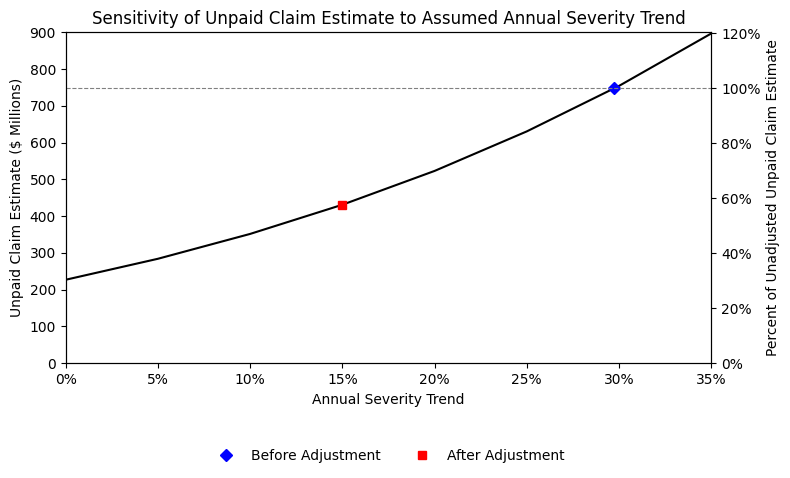

In [21]:
# This work is not really part of the package
# but I'm including it for completeness, it shows the sensitivity of the unpaid claim estimate 
# to the assumed annual severity trend

# Unpaid claim estimate from a reported triangle: 
# Using simple-average LDFs, tail 1.000
# then run chainladder. Returns the all-years total.
def unpaid(tri):
    # Selected LDFs: all-year simple average, rounded like the exhibit
    ldf = np.round(
        cl.Development(average="simple").fit(tri).ldf_.to_frame(origin_as_datetime=False).values.flatten(),
        3,
    )
    developed = cl.DevelopmentConstant(
        patterns=dict(zip([12, 24, 36, 48, 60, 72, 84, 96], [*ldf, 1.0])),
        style="ldf",
    ).fit_transform(tri)
    ult = cl.Chainladder().fit(developed).ultimate_.to_frame(origin_as_datetime=False).iloc[:, 0]
    # Total unpaid = case outstanding + IBNR, with IBNR = ultimate − reported
    return (case_latest.values + ult.values - reported_latest.values).sum()


# unadjusted reported unpaid from Sheet 9
unadj_unpaid = exhibit_i_s9["Total Unpaid Reported (11)"].sum()
selected_trend = 0.15  # trend used on Sheet 6
trends = np.arange(0, 36, 5) / 100

# Re-run Berquist-Sherman and develop at each trend step
adj_unpaid = np.array(
    [
        unpaid(
            cl.BerquistSherman(
                paid_amount="Paid",
                incurred_amount="Incurred",
                reported_count="Reported",
                closed_count="Closed",
                trend=trend,
            )
            .fit(med_mal)
            .adjusted_triangle_["Incurred"]
        )
        for trend in trends
    ]
) / 1e6

# trend where the adjusted estimate equals the unadjusted 
crossing_trend = np.interp(unadj_unpaid / 1e6, adj_unpaid, trends)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(trends, adj_unpaid, color="black", linewidth=1.5)  # sensitivity curve

# blue diamond: unadjusted unpaid
ax.plot(
    crossing_trend,
    unadj_unpaid / 1e6,
    linestyle="None",
    marker="D",
    color="blue",
    label="Before Adjustment",
)

# red square: adjusted unpaid at the 15% selected trend
ax.plot(
    selected_trend,
    adj_unpaid[trends == selected_trend][0],
    linestyle="None",
    marker="s",
    color="red",
    label="After Adjustment",
)

# titles and labels
ax.set_xlabel("Annual Severity Trend")
ax.set_ylabel("Unpaid Claim Estimate ($ Millions)")
ax.set_xlim(0, 0.35)
ax.set_ylim(0, 900)
ax.set_xticks(trends)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2 = ax.twinx()
ax2.set_ylabel("Percent of Unadjusted Unpaid Claim Estimate")
ax2.set_ylim(*(np.array(ax.get_ylim()) * 1e6 / unadj_unpaid))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)
ax.set_title("Sensitivity of Unpaid Claim Estimate to Assumed Annual Severity Trend")
plt.tight_layout()
plt.show()


In [22]:
# Exhibit I Sheet 10 — reconcile to Friedland PDF p303
assert np.isclose(unadj_unpaid, exhibit_i_s9["Total Unpaid Reported (11)"].sum(), atol=1)
assert np.isclose(selected_trend, 0.15)
assert np.isclose(adj_unpaid[trends == selected_trend][0] * 1e6, exhibit_i_s9["Total Unpaid Adj Reported (13)"].sum(), rtol=0.02)


## P304 (Exhibit II Sheet 1)

In [23]:
auto = cl.load_sample("friedland_berq_sher_auto")
paid_auto = auto["Paid Claims"]

# Part 1
display(paid_auto.to_frame(origin_as_datetime=False))

# Part 2
display(np.round(paid_auto.link_ratio.to_frame(origin_as_datetime=False), 3))

# Part 3
dev_paid_auto = cl.Development(average="volume").fit(paid_auto)
display(np.round(dev_paid_auto.ldf_.to_frame(), 3))

# Part 4
selected_ldf = {
    12: 3.098,
    24: 1.444,
    36: 1.196,
    48: 1.087,
    60: 1.036,
    72: 1.019,
    84: 1.006,
    96: 1.000,
}
# or this
avg_ldf = np.round(dev_paid_auto.ldf_.to_frame().values.flatten(), 3)
selected_ldf = dict(zip([12, 24, 36, 48, 60, 72, 84, 96], [*avg_ldf, 1.000]))

paid_auto_dev = cl.DevelopmentConstant(patterns=selected_ldf, style="ldf").fit(paid_auto)
cdf = np.round(paid_auto_dev.cdf_.to_frame().values.flatten(), 3)
pct_paid = np.round(1.0 / cdf, 3)

exhibit_ii_s1_sel = pd.DataFrame(
    {
        "Selected": list(selected_ldf.values()),
        "CDF to Ultimate": cdf,
        "Percent Paid": pct_paid,
    },
    index=["12-24", "24-36", "36-48", "48-60", "60-72", "72-84", "84-96", "96-108"],
)
display(exhibit_ii_s1_sel.T)


,12,24,36,48,60,72,84,96
1969,1904.0,5398.0,7496.0,8882.0,9712.0,10071.0,10199.0,10256.0
1970,2235.0,6261.0,8691.0,10443.0,11346.0,11754.0,12031.0,NaN
1971,2441.0,7348.0,10662.0,12655.0,13748.0,14235.0,NaN,NaN
1972,2503.0,8173.0,11810.0,14176.0,15383.0,NaN,NaN,NaN
1973,2838.0,8712.0,12728.0,15278.0,NaN,NaN,NaN,NaN
1974,2405.0,7858.0,11771.0,NaN,NaN,NaN,NaN,NaN
1975,2759.0,9182.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,2801.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
1969,2.835,1.389,1.185,1.093,1.037,1.013,1.006
1970,2.801,1.388,1.202,1.086,1.036,1.024,NaN
1971,3.010,1.451,1.187,1.086,1.035,NaN,NaN
1972,3.265,1.445,1.200,1.085,NaN,NaN,NaN
1973,3.070,1.461,1.200,NaN,NaN,NaN,NaN
1974,3.267,1.498,NaN,NaN,NaN,NaN,NaN
1975,3.328,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
(All),3.098,1.444,1.196,1.087,1.036,1.019,1.006


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108
Selected,3.098,1.444,1.196,1.087,1.036,1.019,1.006,1.0
CDF to Ultimate,6.176,1.994,1.381,1.154,1.062,1.025,1.006,1.0
Percent Paid,0.162,0.502,0.724,0.867,0.942,0.976,0.994,1.0


In [24]:
# Exhibit II Sheet 1 — reconcile to Friedland PDF p304
assert np.allclose(
    np.round(dev_paid_auto.ldf_.to_frame().values.flatten(), 3),
    [3.098, 1.444, 1.196, 1.087, 1.036, 1.019, 1.006],
)
assert np.allclose(
    exhibit_ii_s1_sel["CDF to Ultimate"],
    [6.170, 1.991, 1.379, 1.154, 1.061, 1.024, 1.006, 1.000],
    atol=0.006,
)
assert np.isclose(paid_auto.to_frame(origin_as_datetime=False).iloc[0, 0], 1904, atol=1)
assert np.isclose(paid_auto.to_frame(origin_as_datetime=False).iloc[-1, 0], 2801, atol=1)


## P305 (Exhibit II Sheet 2)


In [25]:
closed_auto = auto["Closed Claim Counts"]
reported_cnt_auto = auto["Reported Claim Counts"]

display(closed_auto.to_frame(origin_as_datetime=False))
display(reported_cnt_auto.to_frame(origin_as_datetime=False))
display(
    np.round(
        (closed_auto / reported_cnt_auto).to_frame(origin_as_datetime=False),
        3,
    )
)


,12,24,36,48,60,72,84,96
1969,4079.0,6616.0,7192.0,7494.0,7670.0,7749.0,7792.0,7806.0
1970,4429.0,7230.0,7899.0,8291.0,8494.0,8606.0,8647.0,NaN
1971,4914.0,8174.0,9068.0,9518.0,9761.0,9855.0,NaN,NaN
1972,4497.0,7842.0,8747.0,9254.0,9469.0,NaN,NaN,NaN
1973,4419.0,7665.0,8659.0,9093.0,NaN,NaN,NaN,NaN
1974,3486.0,6214.0,6916.0,NaN,NaN,NaN,NaN,NaN
1975,3516.0,6226.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,3230.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96
1969,6553.0,7696.0,7770.0,7799.0,7814.0,7819.0,7820.0,7821.0
1970,7277.0,8537.0,8615.0,8661.0,8675.0,8679.0,8682.0,NaN
1971,8259.0,9765.0,9884.0,9926.0,9940.0,9945.0,NaN,NaN
1972,7858.0,9474.0,9615.0,9664.0,9680.0,NaN,NaN,NaN
1973,7808.0,9376.0,9513.0,9562.0,NaN,NaN,NaN,NaN
1974,6278.0,7614.0,7741.0,NaN,NaN,NaN,NaN,NaN
1975,6446.0,7884.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,6115.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96
1969,0.622,0.860,0.926,0.961,0.982,0.991,0.996,0.998
1970,0.609,0.847,0.917,0.957,0.979,0.992,0.996,NaN
1971,0.595,0.837,0.917,0.959,0.982,0.991,NaN,NaN
1972,0.572,0.828,0.910,0.958,0.978,NaN,NaN,NaN
1973,0.566,0.818,0.910,0.951,NaN,NaN,NaN,NaN
1974,0.555,0.816,0.893,NaN,NaN,NaN,NaN,NaN
1975,0.545,0.790,NaN,NaN,NaN,NaN,NaN,NaN
1976,0.528,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Exhibit II Sheet 2 — reconcile to Friedland PDF p305
closed = closed_auto.to_frame(origin_as_datetime=False)
reported_cnt = reported_cnt_auto.to_frame(origin_as_datetime=False)
ratio = np.round((closed_auto / reported_cnt_auto).to_frame(origin_as_datetime=False), 3)
assert np.isclose(closed.iloc[0, 0], 4079, atol=1)
assert np.isclose(closed.iloc[-1, 0], 3230, atol=1)
assert np.isclose(reported_cnt.iloc[0, 0], 6553, atol=1)
assert np.isclose(reported_cnt.iloc[-1, 0], 6115, atol=1)
assert np.allclose(ratio.iloc[0].astype(float), [0.622, 0.860, 0.926, 0.961, 0.982, 0.991, 0.996, 0.998], atol=0.001)
assert np.isclose(ratio.iloc[-1, 0], 0.528, atol=0.001)


## P306 (Exhibit II Sheet 3)


In [27]:
# Part 1
display(reported_cnt_auto.to_frame(origin_as_datetime=False))

# Part 2
display(np.round(reported_cnt_auto.link_ratio.to_frame(origin_as_datetime=False), 3))

# Part 3
dev_reported_cnt_auto = cl.Development(average="simple").fit(reported_cnt_auto)
display(np.round(dev_reported_cnt_auto.ldf_.to_frame(), 3))

# Part 4
selected_ldf = {
    12: 1.196,
    24: 1.013,
    36: 1.005,
    48: 1.002,
    60: 1.001,
    72: 1.000,
    84: 1.000,
    96: 1.000,
}
# or this
avg_ldf = np.round(dev_reported_cnt_auto.ldf_.to_frame().values.flatten(), 3)
selected_ldf = dict(zip([12, 24, 36, 48, 60, 72, 84, 96], [*avg_ldf, 1.000]))

reported_cnt_auto_dev = cl.DevelopmentConstant(patterns=selected_ldf, style="ldf").fit(
    reported_cnt_auto
)
cdf = np.round(reported_cnt_auto_dev.cdf_.to_frame().values.flatten(), 3)
pct_reported = np.round(1.0 / cdf, 3)

exhibit_ii_s3_sel = pd.DataFrame(
    {
        "Selected": list(selected_ldf.values()),
        "CDF to Ultimate": cdf,
        "Percent Reported": pct_reported,
    },
    index=["12-24", "24-36", "36-48", "48-60", "60-72", "72-84", "84-96", "96-108"],
)
display(exhibit_ii_s3_sel.T)


,12,24,36,48,60,72,84,96
1969,6553.0,7696.0,7770.0,7799.0,7814.0,7819.0,7820.0,7821.0
1970,7277.0,8537.0,8615.0,8661.0,8675.0,8679.0,8682.0,NaN
1971,8259.0,9765.0,9884.0,9926.0,9940.0,9945.0,NaN,NaN
1972,7858.0,9474.0,9615.0,9664.0,9680.0,NaN,NaN,NaN
1973,7808.0,9376.0,9513.0,9562.0,NaN,NaN,NaN,NaN
1974,6278.0,7614.0,7741.0,NaN,NaN,NaN,NaN,NaN
1975,6446.0,7884.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,6115.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
1969,1.174,1.010,1.004,1.002,1.001,1.0,1.0
1970,1.173,1.009,1.005,1.002,1.000,1.0,NaN
1971,1.182,1.012,1.004,1.001,1.001,NaN,NaN
1972,1.206,1.015,1.005,1.002,NaN,NaN,NaN
1973,1.201,1.015,1.005,NaN,NaN,NaN,NaN
1974,1.213,1.017,NaN,NaN,NaN,NaN,NaN
1975,1.223,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
(All),1.196,1.013,1.005,1.002,1.001,1.0,1.0


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108
Selected,1.196,1.013,1.005,1.002,1.001,1.0,1.0,1.0
CDF to Ultimate,1.221,1.021,1.008,1.003,1.001,1.0,1.0,1.0
Percent Reported,0.819,0.979,0.992,0.997,0.999,1.0,1.0,1.0


In [28]:
# Exhibit II Sheet 3 — reconcile to Friedland PDF p306
assert np.allclose(
    np.round(dev_reported_cnt_auto.ldf_.to_frame().values.flatten(), 3),
    [1.196, 1.013, 1.005, 1.002, 1.001, 1.000, 1.000],
)
assert np.allclose(
    exhibit_ii_s3_sel["CDF to Ultimate"],
    [1.221, 1.021, 1.008, 1.003, 1.001, 1.000, 1.000, 1.000],
    atol=0.001,
)


## P307 (Exhibit II Sheet 4)


In [29]:
reported_cnt_latest = reported_cnt_auto.latest_diagonal.to_frame(origin_as_datetime=False).iloc[:, 0]
ages = sorted(reported_cnt_auto.development, reverse=True)
age_to_cdf_reported_cnt = dict(
    zip([12, 24, 36, 48, 60, 72, 84, 96], exhibit_ii_s3_sel["CDF to Ultimate"])
)

# The exhibit applies the CDFs as printed, so feed the rounded CDFs to the method
cl_reported_cnt_auto = cl.Chainladder().fit(
    cl.DevelopmentConstant(patterns=age_to_cdf_reported_cnt, style="cdf").fit_transform(
        reported_cnt_auto
    )
)
ult_reported_cnt = cl_reported_cnt_auto.ultimate_.to_frame(origin_as_datetime=False).iloc[:, 0]

exhibit_ii_s4 = pd.DataFrame(
    {
        "Age (2)": ages,
        "Reported (3)": reported_cnt_latest.values,
        "CDF (4)": [age_to_cdf_reported_cnt[a] for a in ages],
        "Ult (5)": ult_reported_cnt.values,
    },
    index=reported_cnt_latest.index,
)
display(exhibit_ii_s4)
display(exhibit_ii_s4[["Reported (3)", "Ult (5)"]].sum().to_frame("Total").T)


,Age (2),Reported (3),CDF (4),Ult (5)
1969,96,7821.0,1.000,7821.000
1970,84,8682.0,1.000,8682.000
1971,72,9945.0,1.000,9945.000
1972,60,9680.0,1.001,9689.680
1973,48,9562.0,1.003,9590.686
1974,36,7741.0,1.008,7802.928
1975,24,7884.0,1.021,8049.564
1976,12,6115.0,1.221,7466.415


,Reported (3),Ult (5)
Total,67430.0,69047.273


In [30]:
# Exhibit II Sheet 4 — reconcile to Friedland PDF p307
assert np.allclose(
    exhibit_ii_s4["Ult (5)"],
    [7821, 8682, 9945, 9690, 9591, 7803, 8050, 7466],
    atol=2,
)
assert np.isclose(exhibit_ii_s4["Reported (3)"].sum(), 67430, atol=1)
assert np.isclose(exhibit_ii_s4["Ult (5)"].sum(), 69047, atol=2)


## P308 (Exhibit II Sheet 5)


In [31]:
bs_auto = cl.BerquistSherman(
    paid_amount="Paid Claims",
    incurred_amount="Paid Claims", # data not available, only a placeholder, it's not used for the closed-count adjustment
    reported_count="Reported Claim Counts",
    closed_count="Closed Claim Counts",
    reported_count_estimator=cl.Pipeline(
        [
            (
                "dev",
                cl.DevelopmentConstant(
                    patterns=age_to_cdf_reported_cnt, style="cdf"
                ),
            ),
            ("cl", cl.Chainladder()),
        ]
    ),
).fit(auto)

exhibit_ii_s5_disp = np.round(
    bs_auto.disposal_rate_.to_frame(origin_as_datetime=False), 3
)
exhibit_ii_s5_disp["Ult"] = exhibit_ii_s4["Ult (5)"]
display(exhibit_ii_s5_disp)

sel_disp = bs_auto.disposal_rate_
display(
    np.round(
        sel_disp[sel_disp.valuation == auto.valuation_date]
        .mean("origin")
        .to_frame(origin_as_datetime=False),
        3,
    )
)

adj_closed_auto = bs_auto.adjusted_triangle_["Closed Claim Counts"]
display(np.round(adj_closed_auto.to_frame(origin_as_datetime=False)))


,12,24,36,48,60,72,84,96,Ult
1969,0.522,0.846,0.920,0.958,0.981,0.991,0.996,0.998,7821.000
1970,0.510,0.833,0.910,0.955,0.978,0.991,0.996,NaN,8682.000
1971,0.494,0.822,0.912,0.957,0.981,0.991,NaN,NaN,9945.000
1972,0.464,0.809,0.903,0.955,0.977,NaN,NaN,NaN,9689.680
1973,0.461,0.799,0.903,0.948,NaN,NaN,NaN,NaN,9590.686
1974,0.447,0.796,0.886,NaN,NaN,NaN,NaN,NaN,7802.928
1975,0.437,0.773,NaN,NaN,NaN,NaN,NaN,NaN,8049.564
1976,0.433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7466.415


,12,24,36,48,60,72,84,96
1969,0.433,0.773,0.886,0.948,0.977,0.991,0.996,0.998


,12,24,36,48,60,72,84,96
1969,3383.0,6049.0,6932.0,7415.0,7643.0,7750.0,7789.0,7806.0
1970,3756.0,6715.0,7695.0,8231.0,8484.0,8603.0,8647.0,NaN
1971,4302.0,7692.0,8815.0,9429.0,9719.0,9855.0,NaN,NaN
1972,4192.0,7495.0,8588.0,9187.0,9469.0,NaN,NaN,NaN
1973,4149.0,7418.0,8501.0,9093.0,NaN,NaN,NaN,NaN
1974,3376.0,6035.0,6916.0,NaN,NaN,NaN,NaN,NaN
1975,3482.0,6226.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,3230.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Exhibit II Sheet 5 — reconcile to Friedland PDF p308
sel = np.round(
    sel_disp[sel_disp.valuation == auto.valuation_date].mean("origin").to_frame(origin_as_datetime=False).values.flatten(),
    3,
)
assert np.allclose(sel, [0.433, 0.773, 0.886, 0.948, 0.977, 0.991, 0.996, 0.998], atol=0.002)
adj_closed = np.round(adj_closed_auto.to_frame(origin_as_datetime=False))
assert np.allclose(adj_closed.iloc[0].astype(float), [3383, 6049, 6932, 7415, 7643, 7750, 7789, 7806], atol=2)
assert np.isclose(adj_closed.iloc[3, 0], 4192, atol=2)
assert np.isclose(adj_closed.iloc[-1, 0], 3230, atol=1)


## P309 (Exhibit II Sheet 6)


In [33]:
# This calculation falls outside of the scope of this package
from scipy.stats import linregress

closed_df = closed_auto.to_frame(origin_as_datetime=False)
paid_df = paid_auto.to_frame(origin_as_datetime=False)
closed_df.index = [int(getattr(i, "year", i)) for i in closed_df.index]
paid_df.index = [int(getattr(i, "year", i)) for i in paid_df.index]

parts = {}
params = {"R Squared": {}, "a": {}, "b": {}}
for ay in [1969, 1970, 1971]:
    x = closed_df.loc[ay]
    y = paid_df.loc[ay]
    m = x.notna() & y.notna()
    fit = linregress(x[m].astype(float), np.log(y[m].astype(float)))
    a = np.exp(fit.intercept)
    b = fit.slope
    parts[ay] = pd.DataFrame(
        {
            "Closed (X)": x,
            "Paid (Y)": y,
            "Predicted": np.round(a * np.exp(b * x)),
        }
    )
    params["R Squared"][ay] = np.round(fit.rvalue ** 2, 5)
    params["a"][ay] = np.round(a, 3)
    params["b"][ay] = np.round(b, 6)

display(pd.concat(parts, axis=1))
display(pd.DataFrame(params).T)


1969                          1970                          1971  \
   Closed (X) Paid (Y) Predicted Closed (X) Paid (Y) Predicted Closed (X)   
12     4079.0   1904.0    1850.0     4429.0   2235.0    2184.0     4914.0   
24     6616.0   5398.0    5885.0     7230.0   6261.0    6715.0     8174.0   
36     7192.0   7496.0    7653.0     7899.0   8691.0    8781.0     9068.0   
48     7494.0   8882.0    8783.0     8291.0  10443.0   10275.0     9518.0   
60     7670.0   9712.0    9518.0     8494.0  11346.0   11147.0     9761.0   
72     7749.0  10071.0    9867.0     8606.0  11754.0   11659.0     9855.0   
84     7792.0  10199.0   10062.0     8647.0  12031.0   11852.0        NaN   
96     7806.0  10256.0   10127.0        NaN      NaN       NaN        NaN   

                       
   Paid (Y) Predicted  
12   2441.0    2404.0  
24   7348.0    7722.0  
36  10662.0   10634.0  
48  12655.0   12493.0  
60  13748.0   13628.0  
72  14235.0   14095.0  
84      NaN       NaN  
96      NaN       NaN

,1969,1970,1971
R Squared,0.995730,0.997090,0.998660
a,287.742000,369.685000,413.901000
b,0.000456,0.000401,0.000358


In [34]:
# Exhibit II Sheet 6 — reconcile to Friedland PDF p309
params_df = pd.DataFrame(params).T
assert np.allclose(params_df.loc["R Squared"], [0.99573, 0.99709, 0.99866], atol=0.0005)
assert np.allclose(params_df.loc["a"], [287.742, 369.685, 413.901], atol=0.5)
assert np.allclose(params_df.loc["b"], [0.000456, 0.000401, 0.000358], atol=1e-6)


## P310 (Exhibit II Sheet 7)


In [35]:
adj_paid_auto = bs_auto.adjusted_triangle_["Paid Claims"]

display(closed_auto.to_frame(origin_as_datetime=False))
display(paid_auto.to_frame(origin_as_datetime=False))

# Two-point exponential a, b between consecutive ages (same formulas as BerquistSherman).
# The estimator then looks these up onto adjusted closed counts; a_ and b_ are those looked-up values.
x = closed_auto.to_frame(origin_as_datetime=False)
y = paid_auto.to_frame(origin_as_datetime=False)
x0, x1 = x.values[:, :-1], x.values[:, 1:]
y0, y1 = np.log(y.values[:, :-1]), np.log(y.values[:, 1:])

b = ((x0 * y0 + x1 * y1) / 2 - (x0 + x1) / 2 * (y0 + y1) / 2) / (
    (x0 ** 2 + x1 ** 2) / 2 - ((x0 + x1) / 2) ** 2
)
a = np.exp((y0 + y1) / 2 - b * (x0 + x1) / 2)

pair_ages = list(x.columns[:-1])

display(pd.DataFrame(np.round(a), index=x.index, columns=pair_ages))
display(pd.DataFrame(np.round(b, 6), index=x.index, columns=pair_ages))

display(np.round(adj_closed_auto.to_frame(origin_as_datetime=False)))
display(np.round(adj_paid_auto.to_frame(origin_as_datetime=False)))


,12,24,36,48,60,72,84,96
1969,4079.0,6616.0,7192.0,7494.0,7670.0,7749.0,7792.0,7806.0
1970,4429.0,7230.0,7899.0,8291.0,8494.0,8606.0,8647.0,NaN
1971,4914.0,8174.0,9068.0,9518.0,9761.0,9855.0,NaN,NaN
1972,4497.0,7842.0,8747.0,9254.0,9469.0,NaN,NaN,NaN
1973,4419.0,7665.0,8659.0,9093.0,NaN,NaN,NaN,NaN
1974,3486.0,6214.0,6916.0,NaN,NaN,NaN,NaN,NaN
1975,3516.0,6226.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,3230.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96
1969,1904.0,5398.0,7496.0,8882.0,9712.0,10071.0,10199.0,10256.0
1970,2235.0,6261.0,8691.0,10443.0,11346.0,11754.0,12031.0,NaN
1971,2441.0,7348.0,10662.0,12655.0,13748.0,14235.0,NaN,NaN
1972,2503.0,8173.0,11810.0,14176.0,15383.0,NaN,NaN,NaN
1973,2838.0,8712.0,12728.0,15278.0,NaN,NaN,NaN,NaN
1974,2405.0,7858.0,11771.0,NaN,NaN,NaN,NaN,NaN
1975,2759.0,9182.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,2801.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84
1969,356.0,124.0,132.0,198.0,286.0,1034.0,459.0
1970,438.0,181.0,215.0,353.0,778.0,88.0,NaN
1971,464.0,244.0,337.0,493.0,370.0,NaN,NaN
1972,510.0,337.0,506.0,421.0,NaN,NaN,NaN
1973,616.0,468.0,333.0,NaN,NaN,NaN,NaN
1974,530.0,220.0,NaN,NaN,NaN,NaN,NaN
1975,580.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84
1969,0.000411,0.000570,0.000562,0.000508,0.000459,0.000294,0.000398
1970,0.000368,0.000490,0.000468,0.000409,0.000315,0.000568,NaN
1971,0.000338,0.000416,0.000381,0.000341,0.000370,NaN,NaN
1972,0.000354,0.000407,0.000360,0.000380,NaN,NaN,NaN
1973,0.000346,0.000381,0.000421,NaN,NaN,NaN,NaN
1974,0.000434,0.000576,NaN,NaN,NaN,NaN,NaN
1975,0.000444,NaN,NaN,NaN,NaN,NaN,NaN
1976,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96
1969,3383.0,6049.0,6932.0,7415.0,7643.0,7750.0,7789.0,7806.0
1970,3756.0,6715.0,7695.0,8231.0,8484.0,8603.0,8647.0,NaN
1971,4302.0,7692.0,8815.0,9429.0,9719.0,9855.0,NaN,NaN
1972,4192.0,7495.0,8588.0,9187.0,9469.0,NaN,NaN,NaN
1973,4149.0,7418.0,8501.0,9093.0,NaN,NaN,NaN,NaN
1974,3376.0,6035.0,6916.0,NaN,NaN,NaN,NaN,NaN
1975,3482.0,6226.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,3230.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96
1969,1904.0,5398.0,7496.0,8882.0,9712.0,10071.0,10199.0,10256.0
1970,2235.0,6261.0,8691.0,10443.0,11346.0,11754.0,12031.0,NaN
1971,2441.0,7348.0,10662.0,12655.0,13748.0,14235.0,NaN,NaN
1972,2503.0,8173.0,11810.0,14176.0,15383.0,NaN,NaN,NaN
1973,2838.0,8712.0,12728.0,15278.0,NaN,NaN,NaN,NaN
1974,2405.0,7858.0,11771.0,NaN,NaN,NaN,NaN,NaN
1975,2759.0,9182.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,2801.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# Exhibit II Sheet 7 — reconcile to Friedland PDF p310
# Two-point a is stored on the earlier age of each pair (12 for the 12-24 fit).
assert np.isclose(np.round(a)[0, 0], 356, atol=1)
assert np.isclose(np.round(b, 6)[0, 0], 0.000411, atol=1e-6)
assert np.isclose(np.round(a)[1, 2], 215, atol=1)
assert np.isclose(np.round(b, 6)[1, 2], 0.000468, atol=1e-6)
assert np.allclose(
    np.round(adj_closed_auto.to_frame(origin_as_datetime=False)).iloc[0].astype(float),
    [3383, 6049, 6932, 7415, 7643, 7750, 7789, 7806],
    atol=2,
)


## P311 (Exhibit II Sheet 8)


In [37]:
adj_paid_auto = (
    adj_closed_auto * 0 + np.exp(adj_closed_auto.values * bs_auto.b_) * bs_auto.a_
)
adj_paid_auto = (
    paid_auto[paid_auto.valuation == paid_auto.valuation_date]
    + adj_paid_auto[adj_paid_auto.valuation < adj_paid_auto.valuation_date]
)

# Part 1: Data Triangle
display(np.round(adj_paid_auto.to_frame(origin_as_datetime=False)))

# Part 2: Age-to-age factors
display(np.round(adj_paid_auto.link_ratio.to_frame(origin_as_datetime=False), 3))

# Part 3
avg_params = {
    "Simple All Years": {"average": "simple"},
    "Simple Latest 4": {"average": "simple", "n_periods": 4},
    "Volume All Years": {"average": "volume"},
    "Volume Latest 4": {"average": "volume", "n_periods": 4},
}
devs = {k: cl.Development(**v).fit(adj_paid_auto) for k, v in avg_params.items()}
display(
    np.round(
        pd.concat(
            [v.ldf_.to_frame().rename(index={"(All)": k}) for k, v in devs.items()]
        ),
        3,
    )
)
dev_adj_paid_auto = devs["Volume All Years"]

# Part 4
selected_ldf = {
    12: 3.158,
    24: 1.538,
    36: 1.277,
    48: 1.114,
    60: 1.047,
    72: 1.018,
    84: 1.006,
    96: 1.000,
}
# or this
avg_ldf = np.round(dev_adj_paid_auto.ldf_.to_frame().values.flatten(), 3)
selected_ldf = dict(zip([12, 24, 36, 48, 60, 72, 84, 96], [*avg_ldf, 1.000]))

adj_paid_auto_dev = cl.DevelopmentConstant(patterns=selected_ldf, style="ldf").fit(
    adj_paid_auto
)
cdf = np.round(adj_paid_auto_dev.cdf_.to_frame().values.flatten(), 3)
pct_paid = np.round(1.0 / cdf, 3)

exhibit_ii_s8_sel = pd.DataFrame(
    {
        "Unadj Selected": list(exhibit_ii_s1_sel["Selected"]),
        "Adj Selected": list(selected_ldf.values()),
        "CDF to Ultimate": cdf,
        "Percent Paid": pct_paid,
    },
    index=["12-24", "24-36", "36-48", "48-60", "60-72", "72-84", "84-96", "96-108"],
)
display(exhibit_ii_s8_sel.T)


,12,24,36,48,60,72,84,96
1969,1431.0,4277.0,6463.0,8497.0,9579.0,10075.0,10191.0,10256.0
1970,1745.0,5181.0,7865.0,10156.0,11301.0,11744.0,12031.0,NaN
1971,1985.0,6243.0,9594.0,12233.0,13550.0,14235.0,NaN,NaN
1972,2247.0,7228.0,11072.0,13837.0,15383.0,NaN,NaN,NaN
1973,2585.0,7999.0,11982.0,15278.0,NaN,NaN,NaN,NaN
1974,2292.0,7271.0,11771.0,NaN,NaN,NaN,NaN,NaN
1975,2718.0,9182.0,NaN,NaN,NaN,NaN,NaN,NaN
1976,2801.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
1969,2.989,1.511,1.315,1.127,1.052,1.012,1.006
1970,2.969,1.518,1.291,1.113,1.039,1.024,NaN
1971,3.145,1.537,1.275,1.108,1.051,NaN,NaN
1972,3.217,1.532,1.250,1.112,NaN,NaN,NaN
1973,3.094,1.498,1.275,NaN,NaN,NaN,NaN
1974,3.172,1.619,NaN,NaN,NaN,NaN,NaN
1975,3.378,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
Simple All Years,3.138,1.536,1.281,1.115,1.047,1.018,1.006
Simple Latest 4,3.215,1.546,1.273,1.115,1.047,1.018,1.006
Volume All Years,3.158,1.538,1.277,1.114,1.047,1.018,1.006
Volume Latest 4,3.219,1.545,1.271,1.114,1.047,1.018,1.006


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108
Unadj Selected,3.098,1.444,1.196,1.087,1.036,1.019,1.006,1.0
Adj Selected,3.158,1.538,1.277,1.114,1.047,1.018,1.006,1.0
CDF to Ultimate,7.409,2.346,1.525,1.194,1.072,1.024,1.006,1.0
Percent Paid,0.135,0.426,0.656,0.838,0.933,0.977,0.994,1.0


In [38]:
# Exhibit II Sheet 8 — reconcile to Friedland PDF p311
assert np.allclose(
    np.round(adj_paid_auto.to_frame(origin_as_datetime=False)).iloc[0, :3].astype(float),
    [1431, 4277, 6463],
    atol=2,
)
assert np.allclose(
    np.round(devs["Simple All Years"].ldf_.to_frame().values.flatten(), 3),
    [3.138, 1.536, 1.281, 1.115, 1.047, 1.018, 1.006],
)
assert np.allclose(
    np.round(devs["Simple Latest 4"].ldf_.to_frame().values.flatten(), 3),
    [3.215, 1.546, 1.273, 1.115, 1.047, 1.018, 1.006],
)
assert np.allclose(
    np.round(devs["Volume All Years"].ldf_.to_frame().values.flatten(), 3),
    [3.158, 1.538, 1.277, 1.114, 1.047, 1.018, 1.006],
)
assert np.allclose(
    np.round(devs["Volume Latest 4"].ldf_.to_frame().values.flatten(), 3),
    [3.219, 1.545, 1.271, 1.114, 1.047, 1.018, 1.006],
)
assert np.allclose(
    exhibit_ii_s8_sel["Unadj Selected"],
    exhibit_ii_s1_sel["Selected"],
)
assert np.allclose(
    exhibit_ii_s8_sel["CDF to Ultimate"],
    [7.416, 2.348, 1.527, 1.195, 1.073, 1.025, 1.006, 1.000],
    atol=0.01,
)


## P312 (Exhibit II Sheet 9)


In [39]:
from scipy.stats import linregress

ata = adj_paid_auto.link_ratio.to_frame(origin_as_datetime=False)
ata.index = [int(getattr(i, "year", i)) for i in ata.index]
display(np.round(ata, 3))

fits = {}
for col in ata.columns:
    s = ata[col].dropna()
    if len(s) < 3:
        continue
    fits[col] = linregress(s.index.astype(float), s.astype(float))

exhibit_ii_s9_fit = pd.DataFrame(
    {
        col: {
            "Intercept": np.round(fit.intercept, 2),
            "Slope": np.round(fit.slope, 4),
            "R-Squared": np.round(fit.rvalue ** 2, 3),
        }
        for col, fit in fits.items()
    }
)
display(exhibit_ii_s9_fit)

years = list(range(ata.index.min(), ata.index.max() + 2))
completed = ata.reindex(years)
vol_sel = exhibit_ii_s8_sel["Adj Selected"]
for col in completed.columns:
    for yr in years:
        if pd.isna(completed.loc[yr, col]):
            if col in fits and ata[col].notna().sum() >= 4:
                completed.loc[yr, col] = fits[col].intercept + fits[col].slope * yr
            else:
                completed.loc[yr, col] = vol_sel[col]

completed["To Ult"] = 1.000
n_orig = len(years)
completed["CDF to Ultimate"] = [
    completed.loc[yr].iloc[(n_orig - 1 - i) :].prod() for i, yr in enumerate(years)
]
display(np.round(completed, 3))
exhibit_ii_s9 = completed


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
1969,2.989,1.511,1.315,1.127,1.052,1.012,1.006
1970,2.969,1.518,1.291,1.113,1.039,1.024,NaN
1971,3.145,1.537,1.275,1.108,1.051,NaN,NaN
1972,3.217,1.532,1.250,1.112,NaN,NaN,NaN
1973,3.094,1.498,1.275,NaN,NaN,NaN,NaN
1974,3.172,1.619,NaN,NaN,NaN,NaN,NaN
1975,3.378,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72
Intercept,-104.0100,-25.0800,25.0500,11.3600,2.2100
Slope,0.0543,0.0135,-0.0121,-0.0052,-0.0006
R-Squared,0.7030,0.3440,0.6370,0.6100,0.0070


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,To Ult,CDF to Ultimate
1969,2.989,1.511,1.315,1.127,1.052,1.012,1.006,1.0,1.000
1970,2.969,1.518,1.291,1.113,1.039,1.024,1.006,1.0,1.006
1971,3.145,1.537,1.275,1.108,1.051,1.018,1.006,1.0,1.024
1972,3.217,1.532,1.250,1.112,1.047,1.018,1.006,1.0,1.072
1973,3.094,1.498,1.275,1.102,1.047,1.018,1.006,1.0,1.181
1974,3.172,1.619,1.245,1.097,1.047,1.018,1.006,1.0,1.464
1975,3.378,1.583,1.233,1.091,1.047,1.018,1.006,1.0,2.284
1976,3.355,1.596,1.221,1.086,1.047,1.018,1.006,1.0,7.617


In [40]:
# Exhibit II Sheet 9 — reconcile to Friedland PDF p312
assert np.allclose(exhibit_ii_s9_fit.loc["Intercept"], [-104.01, -25.08, 25.05, 11.36, 2.21], atol=0.05)
assert np.allclose(exhibit_ii_s9_fit.loc["Slope"], [0.0543, 0.0135, -0.0121, -0.0052, -0.0006], atol=0.0002)
assert np.allclose(exhibit_ii_s9_fit.loc["R-Squared"], [0.703, 0.344, 0.637, 0.610, 0.007], atol=0.005)
assert np.allclose(
    np.round(exhibit_ii_s9["CDF to Ultimate"], 3),
    [1.000, 1.006, 1.024, 1.073, 1.182, 1.465, 2.285, 7.621],
    atol=0.01,
)


## P313 (Exhibit II Sheet 10)


In [41]:
from scipy.stats import linregress

ata = adj_paid_auto.link_ratio.to_frame(origin_as_datetime=False)
ata.index = [int(getattr(i, "year", i)) for i in ata.index]
display(np.round(ata, 3))

fits = {}
for col in ata.columns:
    s = ata[col].dropna()
    if len(s) < 3:
        continue
    fits[col] = linregress(s.index.astype(float), np.log(s.astype(float)))

exhibit_ii_s10_fit = pd.DataFrame(
    {
        col: {
            "Constant": 0 if np.exp(fit.intercept) < 1 else int(np.round(np.exp(fit.intercept))),
            "Growth": np.round(np.exp(fit.slope), 4),
            "R-Squared": np.round(fit.rvalue ** 2, 3),
        }
        for col, fit in fits.items()
    }
)
display(exhibit_ii_s10_fit)

years = list(range(ata.index.min(), ata.index.max() + 2))
completed = ata.reindex(years)
vol_sel = exhibit_ii_s8_sel["Adj Selected"]
for col in completed.columns:
    for yr in years:
        if pd.isna(completed.loc[yr, col]):
            if col in fits and ata[col].notna().sum() >= 4:
                completed.loc[yr, col] = np.exp(fits[col].intercept + fits[col].slope * yr)
            else:
                completed.loc[yr, col] = vol_sel[col]

completed["To Ult"] = 1.000
n_orig = len(years)
completed["CDF to Ultimate"] = [
    completed.loc[yr].iloc[(n_orig - 1 - i) :].prod() for i, yr in enumerate(years)
]
display(np.round(completed, 3))
exhibit_ii_s10 = completed


,12-24,24-36,36-48,48-60,60-72,72-84,84-96
1969,2.989,1.511,1.315,1.127,1.052,1.012,1.006
1970,2.969,1.518,1.291,1.113,1.039,1.024,NaN
1971,3.145,1.537,1.275,1.108,1.051,NaN,NaN
1972,3.217,1.532,1.250,1.112,NaN,NaN,NaN
1973,3.094,1.498,1.275,NaN,NaN,NaN,NaN
1974,3.172,1.619,NaN,NaN,NaN,NaN,NaN
1975,3.378,NaN,NaN,NaN,NaN,NaN,NaN


,12-24,24-36,36-48,48-60,60-72
Constant,0.0000,0.0000,1.354837e+08,10606.0000,3.0000
Growth,1.0174,1.0086,9.907000e-01,0.9954,0.9994
R-Squared,0.7060,0.3400,6.330000e-01,0.6100,0.0070


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,To Ult,CDF to Ultimate
1969,2.989,1.511,1.315,1.127,1.052,1.012,1.006,1.0,1.000
1970,2.969,1.518,1.291,1.113,1.039,1.024,1.006,1.0,1.006
1971,3.145,1.537,1.275,1.108,1.051,1.018,1.006,1.0,1.024
1972,3.217,1.532,1.250,1.112,1.047,1.018,1.006,1.0,1.072
1973,3.094,1.498,1.275,1.102,1.047,1.018,1.006,1.0,1.182
1974,3.172,1.619,1.245,1.097,1.047,1.018,1.006,1.0,1.465
1975,3.378,1.582,1.234,1.092,1.047,1.018,1.006,1.0,2.285
1976,3.359,1.596,1.222,1.087,1.047,1.018,1.006,1.0,7.634


In [42]:
# Exhibit II Sheet 10 — reconcile to Friedland PDF p313
assert np.allclose(exhibit_ii_s10_fit.loc["Growth"], [1.0174, 1.0086, 0.9907, 0.9954, 0.9994], atol=0.0002)
assert np.allclose(exhibit_ii_s10_fit.loc["R-Squared"], [0.706, 0.340, 0.633, 0.610, 0.007], atol=0.005)
assert np.allclose(
    np.round(exhibit_ii_s10["CDF to Ultimate"], 3),
    [1.000, 1.006, 1.024, 1.073, 1.182, 1.466, 2.286, 7.638],
    atol=0.01,
)
assert np.isclose(np.round(exhibit_ii_s10.loc[1976, "12-24"], 3), 3.359, atol=0.002)


## P314 (Exhibit II Sheet 11)


In [43]:
paid_latest = adj_paid_auto.latest_diagonal.to_frame(origin_as_datetime=False).iloc[:, 0]
paid_latest.index = [int(getattr(i, "year", i)) for i in paid_latest.index]
ages = sorted(paid_auto.development, reverse=True)

age_to_cdf_unadj = dict(
    zip([12, 24, 36, 48, 60, 72, 84, 96], exhibit_ii_s1_sel["CDF to Ultimate"])
)
age_to_cdf_vol = dict(
    zip([12, 24, 36, 48, 60, 72, 84, 96], exhibit_ii_s8_sel["CDF to Ultimate"])
)

cl_unadj_paid_auto = cl.Chainladder().fit(
    cl.DevelopmentConstant(patterns=age_to_cdf_unadj, style="cdf").fit_transform(paid_auto)
)
cl_vol_adj_paid_auto = cl.Chainladder().fit(
    cl.DevelopmentConstant(patterns=age_to_cdf_vol, style="cdf").fit_transform(
        adj_paid_auto
    )
)

cdf_lin = np.round(exhibit_ii_s9["CDF to Ultimate"], 3)
cdf_exp = np.round(exhibit_ii_s10["CDF to Ultimate"], 3)

exhibit_ii_s11 = pd.DataFrame(
    {
        "Age (2)": ages,
        "Adj Paid (3)": paid_latest.values,
        "CDF Unadj (4)": [age_to_cdf_unadj[a] for a in ages],
        "CDF Volume (5)": [age_to_cdf_vol[a] for a in ages],
        "CDF Linear (6)": cdf_lin.values,
        "CDF Exponential (7)": cdf_exp.values,
        "Ult Unadj (8)": cl_unadj_paid_auto.ultimate_.to_frame(origin_as_datetime=False)
        .iloc[:, 0]
        .values,
        "Ult Volume (9)": cl_vol_adj_paid_auto.ultimate_.to_frame(origin_as_datetime=False)
        .iloc[:, 0]
        .values,
        "Ult Linear (10)": paid_latest.values * cdf_lin.values,
        "Ult Exponential (11)": paid_latest.values * cdf_exp.values,
    },
    index=paid_latest.index,
)
display(exhibit_ii_s11)
display(
    exhibit_ii_s11[
        ["Adj Paid (3)", "Ult Unadj (8)", "Ult Volume (9)", "Ult Linear (10)", "Ult Exponential (11)"]
    ]
    .sum()
    .to_frame("Total")
    .T
)


,Age (2),Adj Paid (3),CDF Unadj (4),CDF Volume (5),CDF Linear (6),CDF Exponential (7),Ult Unadj (8),Ult Volume (9),Ult Linear (10),Ult Exponential (11)
1969,96,10256.0,1.000,1.000,1.000,1.000,10256.000,10256.000,10256.000,10256.000
1970,84,12031.0,1.006,1.006,1.006,1.006,12103.186,12103.186,12103.186,12103.186
1971,72,14235.0,1.025,1.024,1.024,1.024,14590.875,14576.640,14576.640,14576.640
1972,60,15383.0,1.062,1.072,1.072,1.072,16336.746,16490.576,16490.576,16490.576
1973,48,15278.0,1.154,1.194,1.181,1.182,17630.812,18241.932,18043.318,18058.596
1974,36,11771.0,1.381,1.525,1.464,1.465,16255.751,17950.775,17232.744,17244.515
1975,24,9182.0,1.994,2.346,2.284,2.285,18308.908,21540.972,20971.688,20980.870
1976,12,2801.0,6.176,7.409,7.617,7.634,17298.976,20752.609,21335.217,21382.834


,Adj Paid (3),Ult Unadj (8),Ult Volume (9),Ult Linear (10),Ult Exponential (11)
Total,90937.0,122781.254,131912.69,131009.369,131093.217


In [44]:
# Exhibit II Sheet 11 — reconcile to Friedland PDF p314
assert np.allclose(exhibit_ii_s11["Adj Paid (3)"], [10256, 12031, 14235, 15383, 15278, 11771, 9182, 2801], atol=1)
assert np.isclose(exhibit_ii_s11["Adj Paid (3)"].sum(), 90937, atol=1)
assert np.isclose(exhibit_ii_s11["Ult Unadj (8)"].sum(), 122684, atol=150)
assert np.isclose(exhibit_ii_s11["Ult Volume (9)"].sum(), 132019, atol=150)
assert np.isclose(exhibit_ii_s11["Ult Linear (10)"].sum(), 131079, atol=150)
assert np.isclose(exhibit_ii_s11["Ult Exponential (11)"].sum(), 131147, atol=150)


## P315 (Exhibit II Sheet 12)


In [45]:
exhibit_ii_s12 = pd.DataFrame(
    {
        "Paid (2)": exhibit_ii_s11["Adj Paid (3)"],
        "Ult Unadj (3)": exhibit_ii_s11["Ult Unadj (8)"],
        "Ult Volume (4)": exhibit_ii_s11["Ult Volume (9)"],
        "Ult Linear (5)": exhibit_ii_s11["Ult Linear (10)"],
        "Ult Exponential (6)": exhibit_ii_s11["Ult Exponential (11)"],
        "Unpaid Unadj (7)": cl_unadj_paid_auto.ibnr_.to_frame(origin_as_datetime=False)
        .iloc[:, 0]
        .values,
        "Unpaid Volume (8)": cl_vol_adj_paid_auto.ibnr_.to_frame(origin_as_datetime=False)
        .iloc[:, 0]
        .values,
        "Unpaid Linear (9)": exhibit_ii_s11["Ult Linear (10)"]
        - exhibit_ii_s11["Adj Paid (3)"],
        "Unpaid Exponential (10)": exhibit_ii_s11["Ult Exponential (11)"]
        - exhibit_ii_s11["Adj Paid (3)"],
    },
    index=exhibit_ii_s11.index,
)
display(exhibit_ii_s12)
display(exhibit_ii_s12.sum().to_frame("Total").T)


,Paid (2),Ult Unadj (3),Ult Volume (4),Ult Linear (5),Ult Exponential (6),Unpaid Unadj (7),Unpaid Volume (8),Unpaid Linear (9),Unpaid Exponential (10)
1969,10256.0,10256.000,10256.000,10256.000,10256.000,NaN,NaN,0.000,0.000
1970,12031.0,12103.186,12103.186,12103.186,12103.186,72.186,72.186,72.186,72.186
1971,14235.0,14590.875,14576.640,14576.640,14576.640,355.875,341.640,341.640,341.640
1972,15383.0,16336.746,16490.576,16490.576,16490.576,953.746,1107.576,1107.576,1107.576
1973,15278.0,17630.812,18241.932,18043.318,18058.596,2352.812,2963.932,2765.318,2780.596
1974,11771.0,16255.751,17950.775,17232.744,17244.515,4484.751,6179.775,5461.744,5473.515
1975,9182.0,18308.908,21540.972,20971.688,20980.870,9126.908,12358.972,11789.688,11798.870
1976,2801.0,17298.976,20752.609,21335.217,21382.834,14497.976,17951.609,18534.217,18581.834


,Paid (2),Ult Unadj (3),Ult Volume (4),Ult Linear (5),Ult Exponential (6),Unpaid Unadj (7),Unpaid Volume (8),Unpaid Linear (9),Unpaid Exponential (10)
Total,90937.0,122781.254,131912.69,131009.369,131093.217,31844.254,40975.69,40072.369,40156.217


In [46]:
# Exhibit II Sheet 12 — reconcile to Friedland PDF p315
assert np.isclose(exhibit_ii_s12["Paid (2)"].sum(), 90937, atol=1)
assert np.isclose(exhibit_ii_s12["Ult Unadj (3)"].sum(), 122684, atol=150)
assert np.isclose(exhibit_ii_s12["Unpaid Unadj (7)"].sum(), 31747, atol=150)
assert np.isclose(exhibit_ii_s12["Unpaid Volume (8)"].sum(), 41082, atol=150)
assert np.isclose(exhibit_ii_s12["Unpaid Linear (9)"].sum(), 40142, atol=150)
assert np.isclose(exhibit_ii_s12["Unpaid Exponential (10)"].sum(), 40210, atol=150)
